In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/cropped.zip"
# !rm -r /content/cropped

Archive:  /content/drive/MyDrive/cropped.zip
   creating: cropped/
  inflating: cropped/Helm-100-_jpg.rf.3d1ca24059a991194bf1ea278a4b115b_crop0.jpg  
  inflating: cropped/Helm-101-_jpg.rf.0d25cc2be68aaaef0ae433f1fa05fa0e_crop0.jpg  
  inflating: cropped/Helm-103-_jpg.rf.7c1f5b7129d08e01bf3359f1ce7f9efe_crop0.jpg  
  inflating: cropped/Helm-103-_jpg.rf.7c1f5b7129d08e01bf3359f1ce7f9efe_crop1.jpg  
  inflating: cropped/Helm-104-_jpg.rf.7aee17aba87d7150f8cc2d62cb16d677_crop0.jpg  
  inflating: cropped/Helm-104-_jpg.rf.7aee17aba87d7150f8cc2d62cb16d677_crop1.jpg  
  inflating: cropped/Helm-105-_jpg.rf.fffb7ce14e35651f95f95c5f98d6fdbc_crop0.jpg  
  inflating: cropped/Helm-106-_jpg.rf.7f80a35e3faaf1dd8044ceefa8402821_crop0.jpg  
  inflating: cropped/Helm-106-_jpg.rf.7f80a35e3faaf1dd8044ceefa8402821_crop1.jpg  
  inflating: cropped/Helm-106-_jpg.rf.7f80a35e3faaf1dd8044ceefa8402821_crop2.jpg  
  inflating: cropped/Helm-109-_jpg.rf.d308d40701c3d0ebfdecc78566eadcc7_crop0.jpg  
  inflating: cropped

In [ ]:
!zip -r "/content/test.zip" "/content/test"

  adding: content/test/ (stored 0%)
  adding: content/test/Helm-169-_jpg.rf.9deba9e96e8e387f74953fe790d547c2.jpg (deflated 2%)
  adding: content/test/.ipynb_checkpoints/ (stored 0%)
  adding: content/test/TidakHelm_7.jpg (deflated 0%)
  adding: content/test/TidakHelm_3.jpg (deflated 0%)
  adding: content/test/TidakHelm.jpg (deflated 2%)
  adding: content/test/TidakHelm_2.jpg (deflated 0%)
  adding: content/test/TidakHelm_4.jpg (deflated 0%)
  adding: content/test/TidakHelm-11-_jpg.rf.5a0f9f06bf8540207bc1b89587cfd5a7_crop0.jpg (deflated 5%)
  adding: content/test/TidakHelm_6.jpg (deflated 2%)
  adding: content/test/Helm-6-_jpg.rf.75cebcb0865c01d79b1429d771227a22.jpg (deflated 0%)
  adding: content/test/Helm.jpg (deflated 0%)
  adding: content/test/IMG-20250526-WA0060_jpg.rf.c954c44f6dfa97daadf969c490077b72_crop0.jpg (deflated 3%)
  adding: content/test/Helm-141-_jpg.rf.125bf6589e731eec21acc05ac8eaee90.jpg (deflated 1%)
  adding: content/test/TidakHelm_8.jpg (deflated 4%)
  adding: conte

In [ ]:
from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def extract_hog_features(image):
    image_resized = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)
    features = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
    return features

In [ ]:
def train_knn(train_data, train_labels):
  hog_features = [extract_hog_features(image) for image in train_data]
  knn = KNeighborsClassifier(n_neighbors=5)
  knn.fit(hog_features, train_labels)
  return knn

In [ ]:
def predict_knn(knn, test_data):
  hog_features = extract_hog_features(test_data)
  return knn.predict([hog_features])

In [ ]:
def show_predictions(knn_classifier, X_test, y_test, num_samples=10):
    plt.figure(figsize=(15, 5))

    for i in range(min(num_samples, len(X_test))):
        img = X_test[i]
        true_label = y_test[i]
        pred_label = predict_knn(knn_classifier, img)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=[0, 1], class_names=["Helm", "Tidak Helm"]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
import random

def augment_image(image):
    augmented_images = []
    rows, cols = image.shape[:2]

    # Rotasi
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
        rotated = cv2.warpAffine(image, M, (cols, rows), borderMode=cv2.BORDER_REFLECT)
        augmented_images.append(rotated)

    # Brightness
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    factor = random.uniform(0.7, 1.3)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 75, 170)
    brighter = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    augmented_images.append(brighter)

    return augmented_images


Jumlah data latih: 226
Jumlah data uji: 57
Jumlah helm: 139
Jumlah tidak helm: 144
Akurasi: 0.8070175438596491

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.71      0.96      0.82        26
           1       0.95      0.68      0.79        31

    accuracy                           0.81        57
   macro avg       0.83      0.82      0.81        57
weighted avg       0.84      0.81      0.80        57


=== Confusion Matrix ===
[[25  1]
 [10 21]]


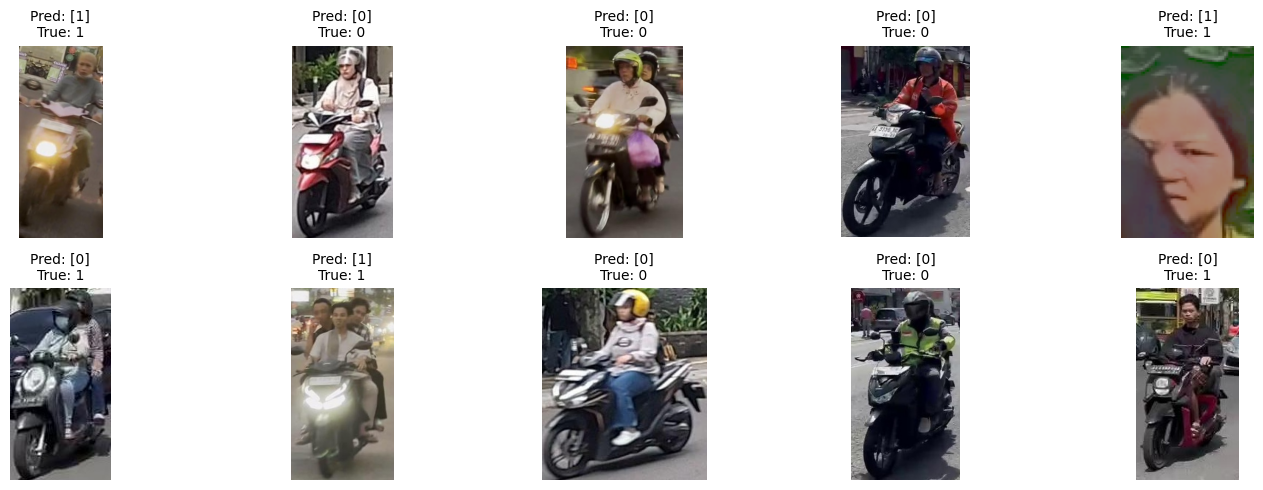

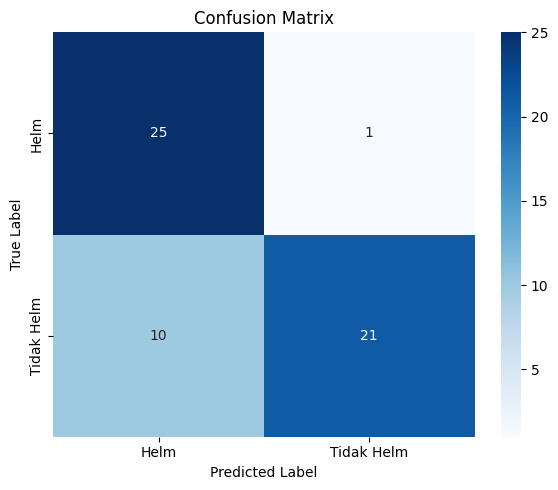

In [ ]:
  train_folder = "/content/cropped"
  test_folder = "/content/test"

  train_data, train_labels = [], []
  test_data, test_labels = [], []
  helm = 0
  tidak_helm = 0

  for filename in os.listdir(train_folder):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            path = os.path.join(train_folder, filename)
            img = cv2.imread(path)

            if img is None:
                print(f"[!] Gagal membuka gambar: {filename}")
                continue

            if "TidakHelm" in filename:
                label = 1
                train_data.append(img)
                train_labels.append(label)
                tidak_helm += 1

                if tidak_helm < 105:
                  augmented_images = augment_image(img)
                  for aug_img in augmented_images:
                      if tidak_helm >= 105:
                          break
                      train_data.append(aug_img)
                      train_labels.append(label)
                      tidak_helm += 1

            elif "Helm" in filename:
                label = 0
                train_data.append(img)
                train_labels.append(label)
                helm += 1

            else:
                label = 0
                train_data.append(img)
                train_labels.append(label)
                helm += 1

  for filename in os.listdir(test_folder):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            path = os.path.join(test_folder, filename)
            img = cv2.imread(path)
            if img is None:
                print(f"[!] Gagal membuka gambar (test): {filename}")
                continue

            if "TidakHelm" in filename:
                label = 1
            else:
                label = 0

            test_data.append(img)
            test_labels.append(label)

  ## Dataset Split
  X_train, X_test, y_train, y_test = train_test_split(train_data, train_labels, test_size=0.2, random_state=42)

  print("Jumlah data latih:", len(X_train))
  print("Jumlah data uji:", len(X_test))
  print("Jumlah helm:", helm)
  print("Jumlah tidak helm:", tidak_helm)

  knn_classifier = train_knn(X_train, y_train)

  y_pred = [predict_knn(knn_classifier, img)[0] for img in X_test]

  accuracy = np.mean(np.array(y_pred) == np.array(y_test))
  print("Akurasi:", accuracy)

  print("\n=== Classification Report ===")
  print(classification_report(y_test, y_pred))

  print("\n=== Confusion Matrix ===")
  print(confusion_matrix(y_test, y_pred))

  show_predictions(knn_classifier, X_test, y_test)
  plot_confusion_matrix(y_test, y_pred)

Jumlah data latih: 283
Jumlah data uji: 14
Jumlah helm: 139
Jumlah tidak helm: 144
Akurasi: 0.7142857142857143

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.69      1.00      0.82         9
           1       1.00      0.20      0.33         5

    accuracy                           0.71        14
   macro avg       0.85      0.60      0.58        14
weighted avg       0.80      0.71      0.65        14


=== Confusion Matrix ===
[[9 0]
 [4 1]]


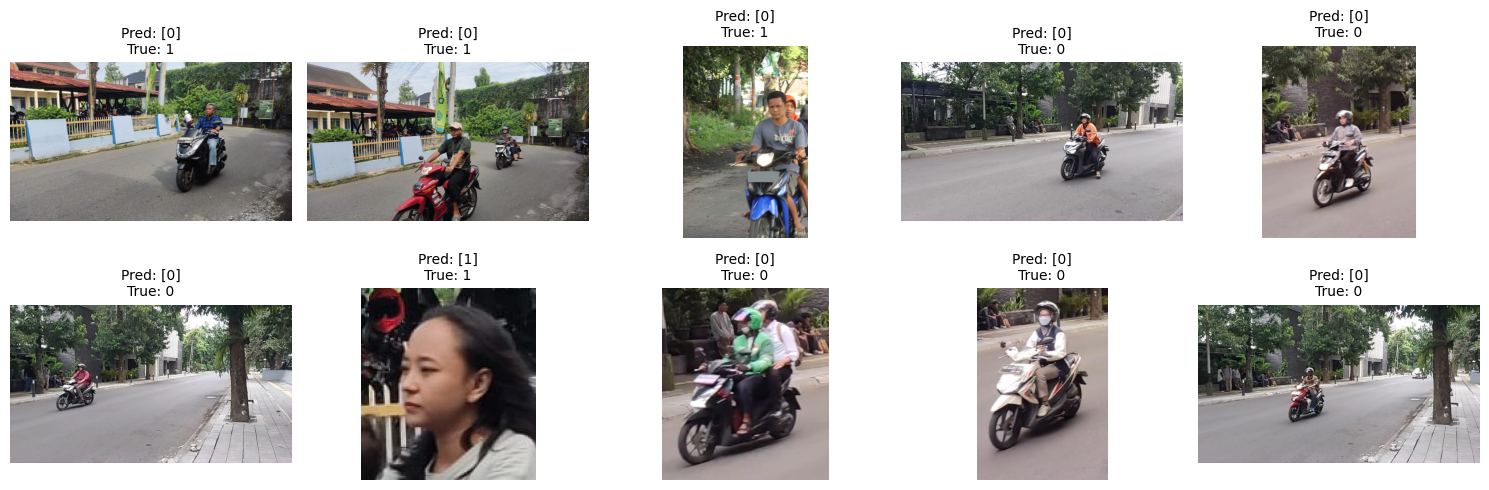

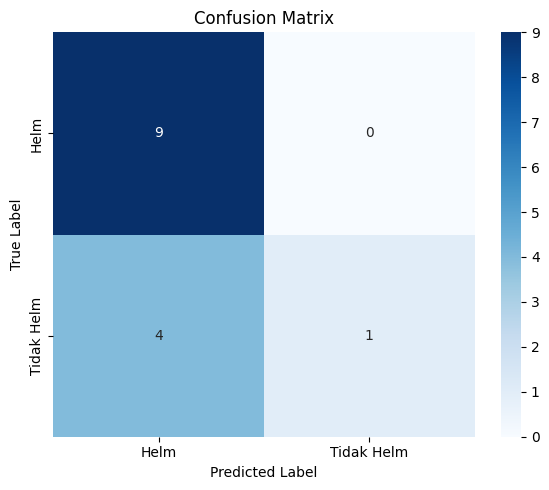

In [ ]:
  ## Dataset Luar
  X_train, y_train = train_data, train_labels
  X_test, y_test = test_data, test_labels

  print("Jumlah data latih:", len(X_train))
  print("Jumlah data uji:", len(X_test))
  print("Jumlah helm:", helm)
  print("Jumlah tidak helm:", tidak_helm)

  knn_classifier = train_knn(X_train, y_train)

  y_pred = [predict_knn(knn_classifier, img)[0] for img in X_test]

  accuracy = np.mean(np.array(y_pred) == np.array(y_test))
  print("Akurasi:", accuracy)

  print("\n=== Classification Report ===")
  print(classification_report(y_test, y_pred))

  print("\n=== Confusion Matrix ===")
  print(confusion_matrix(y_test, y_pred))

  show_predictions(knn_classifier, X_test, y_test)
  plot_confusion_matrix(y_test, y_pred)